In [16]:
import os
from dotenv import load_dotenv
import tushare as ts

In [17]:
# 加载.env文件到环境变量
load_dotenv()

# 从环境变量获取token
token = os.getenv('TUSHARE_TOKEN')
print(f"Token: {token}")

Token: 2d90a0b03e11c3de51f382b38b29142f1a4e50f70f335d74b954b1b3


In [18]:
# 使用token
pro = ts.pro_api(token)
df = pro.daily(trade_date='20200325')

In [19]:
print(f"✅ 成功获取数据：{len(df)}条记录")
print("前5条数据：")
print(df.head())

✅ 成功获取数据：3860条记录
前5条数据：
     ts_code trade_date   open   high    low  close  pre_close  change  \
0  002507.SZ   20200325  30.79  31.07  29.11  29.90      30.11   -0.21   
1  603366.SH   20200325   5.68   5.74   5.57   5.65       5.55    0.10   
2  603369.SH   20200325  27.11  28.06  26.86  27.72      26.43    1.29   
3  002519.SZ   20200325   4.82   4.84   4.62   4.68       4.69   -0.01   
4  603389.SH   20200325   4.50   4.54   4.43   4.53       4.43    0.10   

   pct_chg        vol      amount  
0  -0.6974  263059.08  783721.546  
1   1.8018  129442.82   73156.302  
2   4.8808  134490.08  368846.960  
3  -0.2132  335282.74  158588.520  
4   2.2573   27885.80   12520.168  


=== 基础概率演示 ===


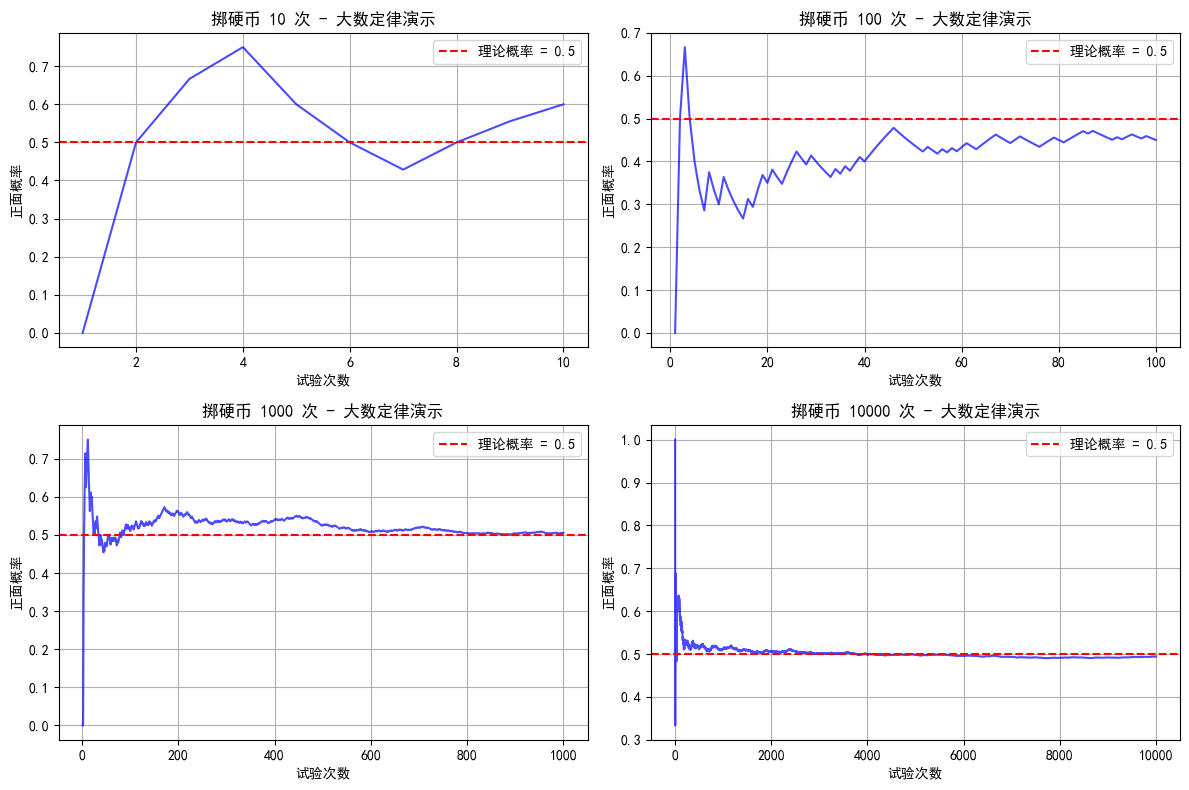

理论概率: 0.5
实际概率: 0.4940
误差: 0.0060

=== 常见概率分布对比 ===


/var/folders/n4/h9n8yzln7p36y_wtxx0vxx9c0000gn/T/ipykernel_69960/1747776846.py:124: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/quant/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


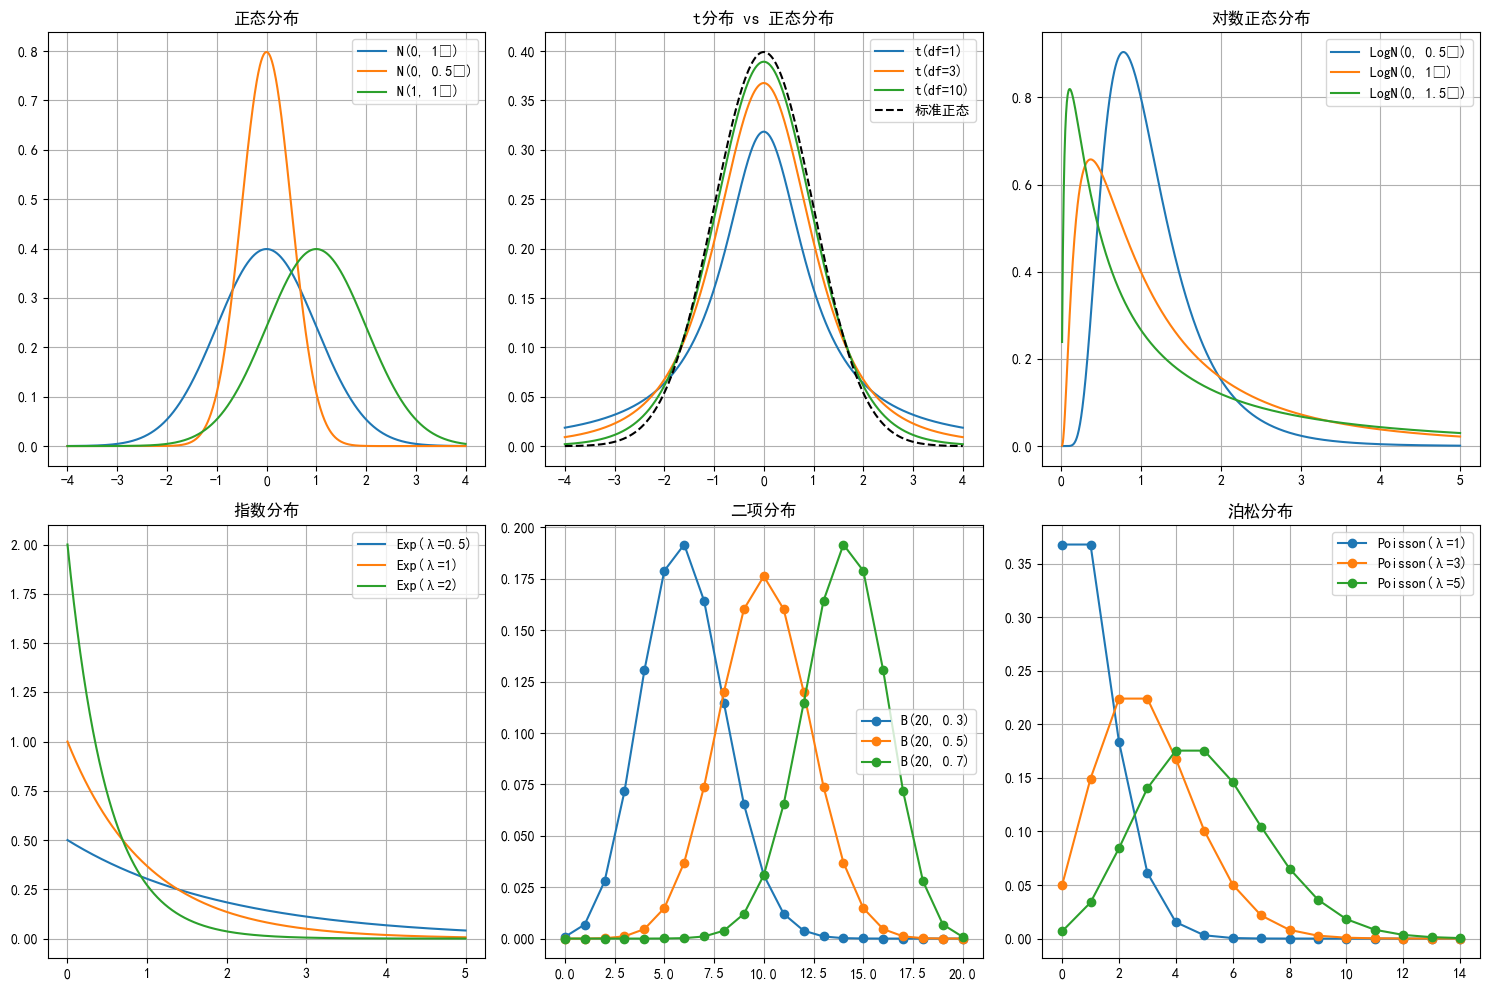


=== 贝叶斯定理应用演示 ===
先验概率 - 上涨: 50.0%, 下跌: 50.0%
指标准确性 - 上涨时买入信号: 80.0%
指标准确性 - 下跌时买入信号: 30.0%
后验概率 - 买入信号后上涨: 72.7%
后验概率 - 买入信号后下跌: 27.3%


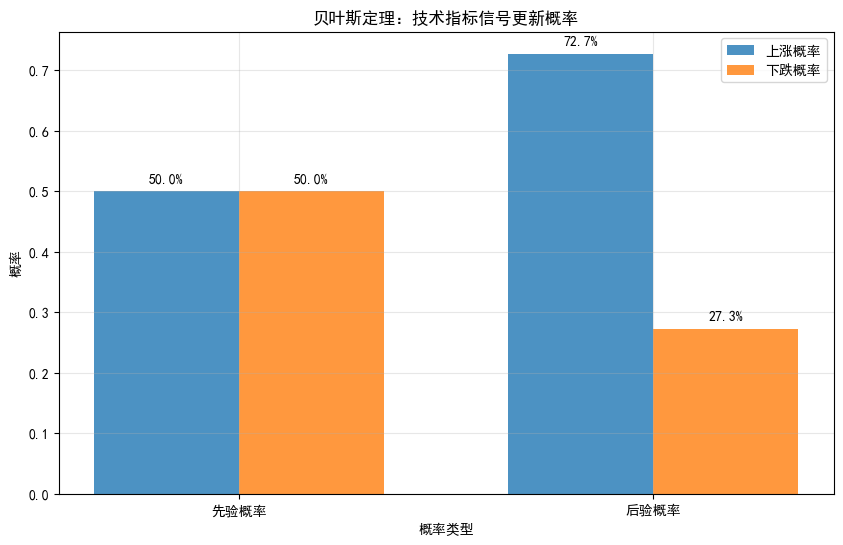


=== 中心极限定理演示 ===


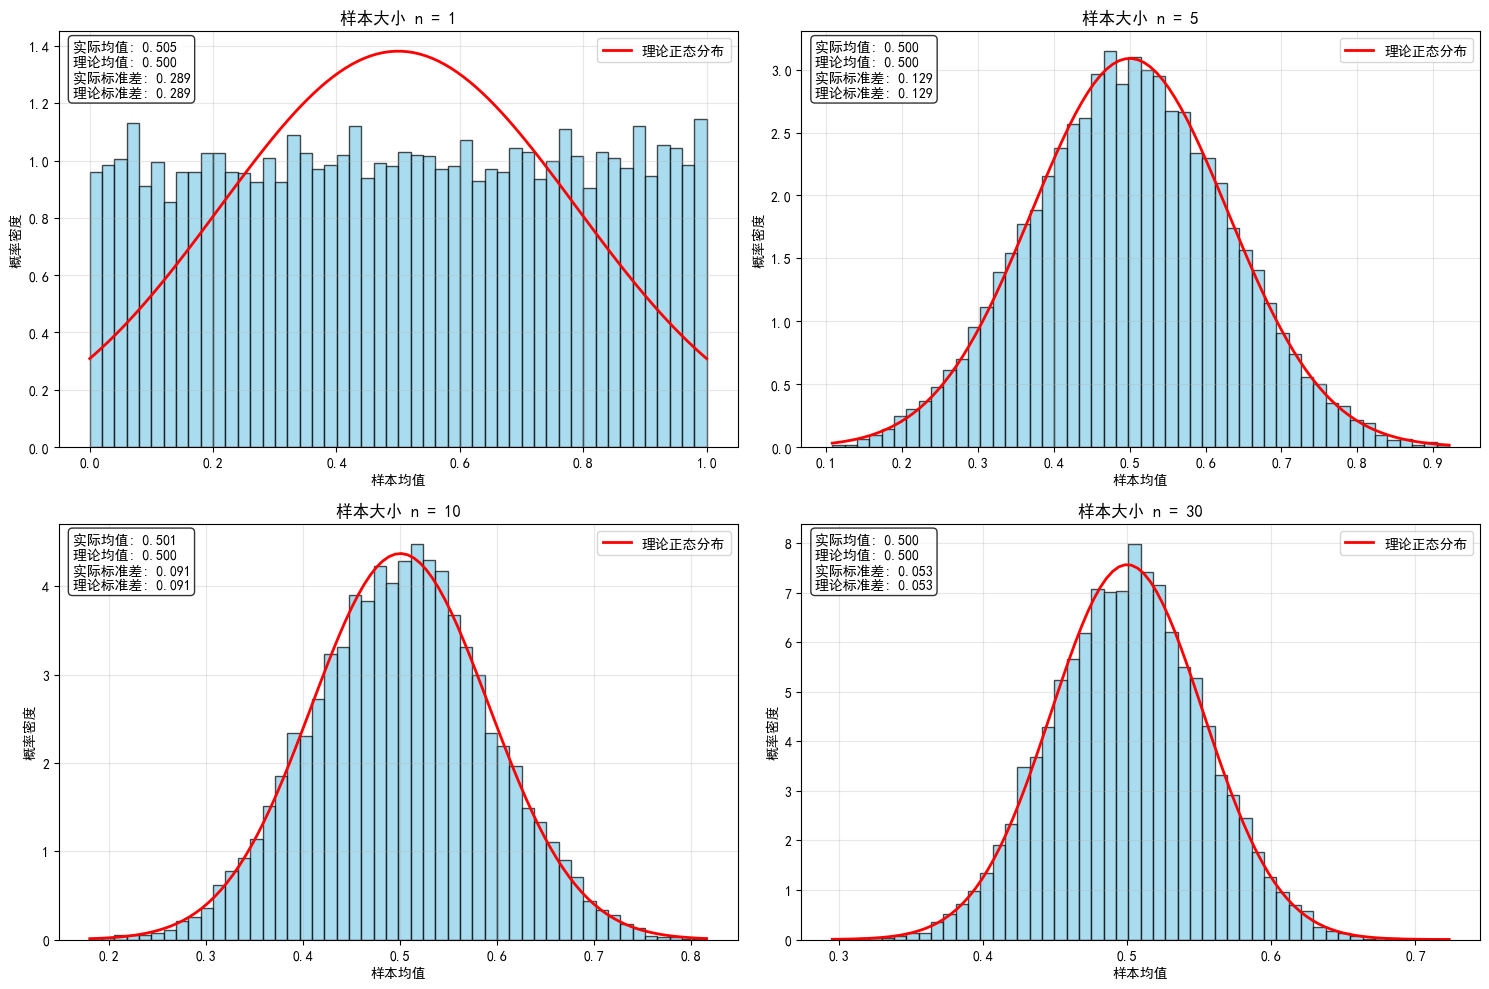

观察：随着样本量增加，样本均值分布越来越接近正态分布
=== 量化交易概率应用示例 ===

1. 策略期望收益计算
胜率: 65.0%
平均盈利: 8.0%
平均亏损: -5.0%
期望收益: 3.45%

2. 凯利公式最优仓位
赔率 b: 1.60
最优仓位: 43.13%

3. VaR风险价值计算
组合价值: 1,000,000
日均收益: 0.08%
日波动率: 1.5%
95% VaR: 23,873 元

4. 连续亏损概率分析


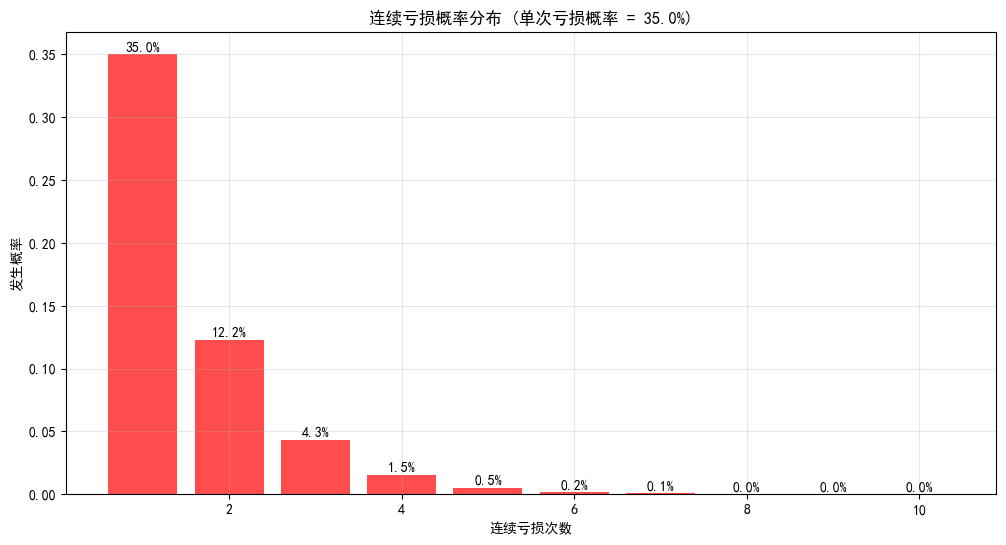

连续亏损概率：
连续亏损1次: 35.00%
连续亏损2次: 12.25%
连续亏损3次: 4.29%
连续亏损4次: 1.50%
连续亏损5次: 0.53%


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

class ProbabilityAnalyzer:
    """概率分析工具类"""
    
    def __init__(self):
        self.random_seed = 42
        np.random.seed(self.random_seed)
    
    def basic_probability_demo(self):
        """基础概率演示"""
        print("=== 基础概率演示 ===")
        
        # 掷硬币实验
        n_trials = [10, 100, 1000, 10000]
        true_prob = 0.5
        
        plt.figure(figsize=(12, 8))
        
        for i, n in enumerate(n_trials):
            # 模拟掷硬币
            coins = np.random.binomial(1, 0.5, n)
            
            # 计算累计概率
            cumsum = np.cumsum(coins)
            trials = np.arange(1, n+1)
            running_prob = cumsum / trials
            
            plt.subplot(2, 2, i+1)
            plt.plot(trials, running_prob, 'b-', alpha=0.7)
            plt.axhline(y=true_prob, color='r', linestyle='--', 
                       label=f'理论概率 = {true_prob}')
            plt.title(f'掷硬币 {n} 次 - 大数定律演示')
            plt.xlabel('试验次数')
            plt.ylabel('正面概率')
            plt.legend()
            plt.grid(True)
            
        plt.tight_layout()
        plt.show()
        
        # 最终结果
        final_prob = running_prob[-1]
        print(f"理论概率: {true_prob}")
        print(f"实际概率: {final_prob:.4f}")
        print(f"误差: {abs(final_prob - true_prob):.4f}")
    
    def distribution_comparison(self):
        """常见分布对比"""
        print("\n=== 常见概率分布对比 ===")
        
        x = np.linspace(-4, 4, 1000)
        
        plt.figure(figsize=(15, 10))
        
        # 正态分布
        plt.subplot(2, 3, 1)
        for mu, sigma in [(0, 1), (0, 0.5), (1, 1)]:
            y = stats.norm.pdf(x, mu, sigma)
            plt.plot(x, y, label=f'N({mu}, {sigma}²)')
        plt.title('正态分布')
        plt.legend()
        plt.grid(True)
        
        # t分布
        plt.subplot(2, 3, 2)
        for df in [1, 3, 10]:
            y = stats.t.pdf(x, df)
            plt.plot(x, y, label=f't(df={df})')
        y_norm = stats.norm.pdf(x, 0, 1)
        plt.plot(x, y_norm, 'k--', label='标准正态')
        plt.title('t分布 vs 正态分布')
        plt.legend()
        plt.grid(True)
        
        # 对数正态分布
        plt.subplot(2, 3, 3)
        x_log = np.linspace(0.01, 5, 1000)
        for sigma in [0.5, 1, 1.5]:
            y = stats.lognorm.pdf(x_log, sigma)
            plt.plot(x_log, y, label=f'LogN(0, {sigma}²)')
        plt.title('对数正态分布')
        plt.legend()
        plt.grid(True)
        
        # 指数分布
        plt.subplot(2, 3, 4)
        x_exp = np.linspace(0, 5, 1000)
        for lam in [0.5, 1, 2]:
            y = stats.expon.pdf(x_exp, scale=1/lam)
            plt.plot(x_exp, y, label=f'Exp(λ={lam})')
        plt.title('指数分布')
        plt.legend()
        plt.grid(True)
        
        # 二项分布
        plt.subplot(2, 3, 5)
        x_binom = np.arange(0, 21)
        for n, p in [(20, 0.3), (20, 0.5), (20, 0.7)]:
            y = stats.binom.pmf(x_binom, n, p)
            plt.plot(x_binom, y, 'o-', label=f'B({n}, {p})')
        plt.title('二项分布')
        plt.legend()
        plt.grid(True)
        
        # 泊松分布
        plt.subplot(2, 3, 6)
        x_poisson = np.arange(0, 15)
        for lam in [1, 3, 5]:
            y = stats.poisson.pmf(x_poisson, lam)
            plt.plot(x_poisson, y, 'o-', label=f'Poisson(λ={lam})')
        plt.title('泊松分布')
        plt.legend()
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()
    
    def bayes_theorem_demo(self):
        """贝叶斯定理演示"""
        print("\n=== 贝叶斯定理应用演示 ===")
        
        # 场景：技术指标预测股价
        prior_up = 0.5      # 先验：股价上涨概率
        prior_down = 0.5    # 先验：股价下跌概率
        
        # 似然：技术指标的准确性
        indicator_given_up = 0.8    # 上涨时指标显示买入
        indicator_given_down = 0.3  # 下跌时指标显示买入
        
        # 计算边际概率
        prob_indicator = (indicator_given_up * prior_up + 
                         indicator_given_down * prior_down)
        
        # 计算后验概率
        posterior_up = (indicator_given_up * prior_up) / prob_indicator
        posterior_down = (indicator_given_down * prior_down) / prob_indicator
        
        print(f"先验概率 - 上涨: {prior_up:.1%}, 下跌: {prior_down:.1%}")
        print(f"指标准确性 - 上涨时买入信号: {indicator_given_up:.1%}")
        print(f"指标准确性 - 下跌时买入信号: {indicator_given_down:.1%}")
        print(f"后验概率 - 买入信号后上涨: {posterior_up:.1%}")
        print(f"后验概率 - 买入信号后下跌: {posterior_down:.1%}")
        
        # 可视化
        categories = ['先验概率', '后验概率']
        up_probs = [prior_up, posterior_up]
        down_probs = [prior_down, posterior_down]
        
        x = np.arange(len(categories))
        width = 0.35
        
        plt.figure(figsize=(10, 6))
        plt.bar(x - width/2, up_probs, width, label='上涨概率', alpha=0.8)
        plt.bar(x + width/2, down_probs, width, label='下跌概率', alpha=0.8)
        
        plt.xlabel('概率类型')
        plt.ylabel('概率')
        plt.title('贝叶斯定理：技术指标信号更新概率')
        plt.xticks(x, categories)
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        for i, (up, down) in enumerate(zip(up_probs, down_probs)):
            plt.text(i - width/2, up + 0.01, f'{up:.1%}', 
                    ha='center', va='bottom')
            plt.text(i + width/2, down + 0.01, f'{down:.1%}', 
                    ha='center', va='bottom')
        
        plt.show()
    
    def central_limit_theorem_demo(self):
        """中心极限定理演示"""
        print("\n=== 中心极限定理演示 ===")
        
        # 原始分布：均匀分布（非正态）
        original_dist = stats.uniform(loc=0, scale=1)
        
        sample_sizes = [1, 5, 10, 30]
        n_samples = 10000
        
        plt.figure(figsize=(15, 10))
        
        for i, n in enumerate(sample_sizes):
            # 生成样本均值
            samples = original_dist.rvs(size=(n_samples, n))
            sample_means = np.mean(samples, axis=1)
            
            plt.subplot(2, 2, i+1)
            
            # 绘制直方图
            plt.hist(sample_means, bins=50, density=True, 
                    alpha=0.7, color='skyblue', edgecolor='black')
            
            # 理论正态分布
            theoretical_mean = 0.5  # 均匀分布均值
            theoretical_std = 1/np.sqrt(12*n)  # 均匀分布方差/n
            
            x = np.linspace(sample_means.min(), sample_means.max(), 100)
            theoretical_pdf = stats.norm.pdf(x, theoretical_mean, theoretical_std)
            plt.plot(x, theoretical_pdf, 'r-', linewidth=2, 
                    label='理论正态分布')
            
            plt.title(f'样本大小 n = {n}')
            plt.xlabel('样本均值')
            plt.ylabel('概率密度')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            # 计算统计量
            actual_mean = np.mean(sample_means)
            actual_std = np.std(sample_means)
            
            plt.text(0.02, 0.98, 
                    f'实际均值: {actual_mean:.3f}\n'
                    f'理论均值: {theoretical_mean:.3f}\n'
                    f'实际标准差: {actual_std:.3f}\n'
                    f'理论标准差: {theoretical_std:.3f}',
                    transform=plt.gca().transAxes,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
        print("观察：随着样本量增加，样本均值分布越来越接近正态分布")

def trading_probability_examples():
    """量化交易概率应用示例"""
    print("=== 量化交易概率应用示例 ===")
    
    # 1. 计算策略期望收益
    print("\n1. 策略期望收益计算")
    win_rate = 0.65
    avg_win = 0.08
    avg_loss = -0.05
    
    expected_return = win_rate * avg_win + (1 - win_rate) * avg_loss
    print(f"胜率: {win_rate:.1%}")
    print(f"平均盈利: {avg_win:.1%}")
    print(f"平均亏损: {avg_loss:.1%}")
    print(f"期望收益: {expected_return:.2%}")
    
    # 2. 凯利公式计算最优仓位
    print("\n2. 凯利公式最优仓位")
    b = abs(avg_win / avg_loss)  # 赔率
    p = win_rate
    q = 1 - win_rate
    
    kelly_fraction = (b * p - q) / b
    print(f"赔率 b: {b:.2f}")
    print(f"最优仓位: {kelly_fraction:.2%}")
    
    # 3. 风险价值计算
    print("\n3. VaR风险价值计算")
    portfolio_value = 1000000  # 100万组合
    daily_return_mean = 0.0008
    daily_return_std = 0.015
    confidence_level = 0.95
    
    # 参数法VaR
    z_score = stats.norm.ppf(1 - confidence_level)
    var_parametric = portfolio_value * (daily_return_mean + z_score * daily_return_std)
    
    print(f"组合价值: {portfolio_value:,}")
    print(f"日均收益: {daily_return_mean:.2%}")
    print(f"日波动率: {daily_return_std:.1%}")
    print(f"95% VaR: {-var_parametric:,.0f} 元")
    
    # 4. 连续亏损概率
    print("\n4. 连续亏损概率分析")
    loss_prob = 1 - win_rate
    
    consecutive_losses = range(1, 11)
    probabilities = [loss_prob ** n for n in consecutive_losses]
    
    plt.figure(figsize=(12, 6))
    plt.bar(consecutive_losses, probabilities, alpha=0.7, color='red')
    plt.xlabel('连续亏损次数')
    plt.ylabel('发生概率')
    plt.title(f'连续亏损概率分布 (单次亏损概率 = {loss_prob:.1%})')
    plt.grid(True, alpha=0.3)
    
    for i, prob in enumerate(probabilities):
        plt.text(i+1, prob + 0.001, f'{prob:.1%}', 
                ha='center', va='bottom')
    
    plt.show()
    
    print("连续亏损概率：")
    for n, prob in zip(consecutive_losses[:5], probabilities[:5]):
        print(f"连续亏损{n}次: {prob:.2%}")

def main():
    """主函数"""
    # 创建概率分析器
    analyzer = ProbabilityAnalyzer()
    
    # 运行演示
    analyzer.basic_probability_demo()
    analyzer.distribution_comparison()
    analyzer.bayes_theorem_demo()
    analyzer.central_limit_theorem_demo()
    
    # 交易应用示例
    trading_probability_examples()

if __name__ == "__main__":
    main()

=== 基础概率演示 ===


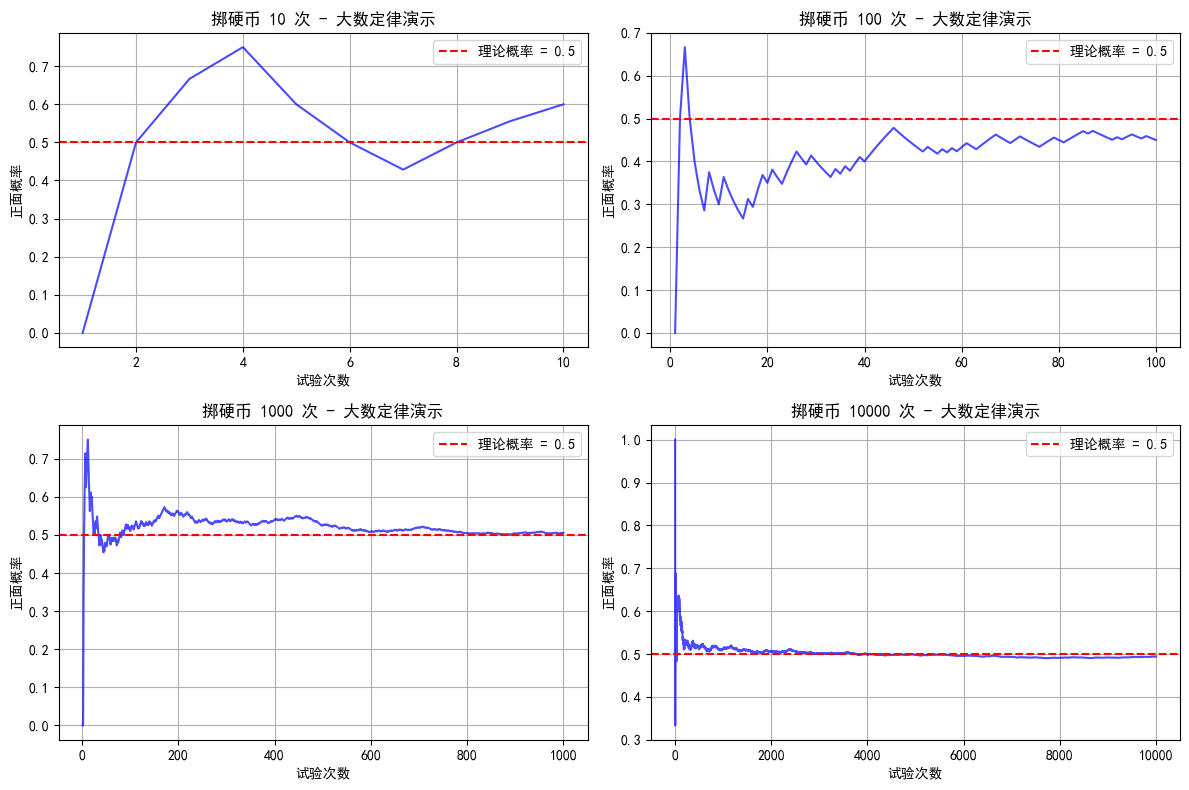

理论概率: 0.5
实际概率: 0.4940
误差: 0.0060


In [3]:
analyzer1 = ProbabilityAnalyzer()

# 运行演示
analyzer1.basic_probability_demo()